In [1]:
#pip install scikit-optimize
%matplotlib inline

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

import datagen as gen

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


from scipy.special import huber

from sklearn.metrics import make_scorer, mean_pinball_loss, mean_squared_error, mean_absolute_error

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

## Load in the data

In [3]:
#df = gen.load_data_mini() #for testing purposes, use a smaller dataset to speed up the process
df = gen.load_train_data() #for full dataset

df['LENGTH_OF_STAY'] = df['LENGTH_OF_STAY'].clip(upper=30)

In [4]:
X_train, X_test, y_train, y_test, los_train, los_test = train_test_split(
    df.drop(columns=['LENGTH_OF_STAY', 'PROLONGED', 'STRATA']),
    df['PROLONGED'],
    df['LENGTH_OF_STAY'],
    test_size=0.2,
    stratify=df['STRATA']
)

## Preprocessing

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), gen.num_feats),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), gen.cat_features)
    ],
    remainder="passthrough"  
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestClassifier(n_estimators=100, n_jobs=-1))
])

## Hyperparameter tuning for classifier

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True)

search_space = {
    'regressor__n_estimators': Integer(100, 500),
    'regressor__max_depth': Integer(5, 50),
}

bayes_search = BayesSearchCV(
    estimator=model_pipeline,
    search_spaces=search_space,
    n_iter=50,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

random_indices = random.sample(range(len(y_train)), 100_000)  # Randomly sample 100,000 indices
random_indices.sort()
# random_indices


In [7]:
X_train.head()

,TYPE_OF_ADMISSION,SOURCE_OF_ADMISSION,PUBLIC_HEALTH_REGION,SEX_CODE,RACE,ETHNICITY,ADMIT_WEEKDAY,PAT_AGE,EMERGENCY_DEPT_FLAG,CODE_1,...,PAT_RURAL,PROVIDER_RURAL,PAT2PROV_DISTANCE,QUARTER,YEAR,PAT_LATITUDE,PAT_LONGITUDE,PROVIDER_LATITUDE,PROVIDER_LONGITUDE,NUM_CODES
1280224,1,1,6,F,2,2,2,16,1,0,...,0,0,8.565275,3,2017,30.0377,-95.5326,30.0167,-95.4470,4
5599391,1,1,11,F,4,1,3,13,1,1,...,0,0,6.356756,4,2019,25.9717,-97.4699,25.9337,-97.5174,8
586839,1,1,6,F,4,2,7,9,0,0,...,0,0,9.456088,2,2017,29.7450,-95.7326,29.7404,-95.8304,2
4902853,1,1,6,F,2,2,5,10,1,0,...,0,0,3.166008,3,2019,29.5975,-95.1134,29.5716,-95.0998,5
159141,1,1,5,F,4,1,5,2,1,0,...,0,0,8.842075,1,2017,31.6737,-94.6932,31.7195,-94.6168,3


In [8]:
bayes_search.fit(X_train.iloc[random_indices,:], y_train.iloc[random_indices])

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

/opt/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(12), np.int64(500)] before, using random point [np.int64(9), np.int64(187)]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(12), np.int64(500)] before, using random point [np.int64(11), np.int64(190)]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,Pipeline(step...(n_jobs=-1))])
,search_spaces,"{'regressor__max_depth': Integer(low=5...m='normalize'), 'regressor__n_estimators': Integer(low=1...m='normalize')}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'average_precision'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,StratifiedKFo... shuffle=True)


In [9]:
best_model = bayes_search.best_estimator_

## Validation of classifier

In [10]:
from sklearn.metrics import average_precision_score, confusion_matrix, recall_score, precision_score, f1_score

In [11]:
y_prob = best_model.predict_proba(X_test)[:,1]  # Get the probabilities for the positive class

In [12]:
thresholds = np.linspace(0, 1, 100)

rows = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    rows.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "avera": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn
    })

threshold_results = pd.DataFrame(rows)

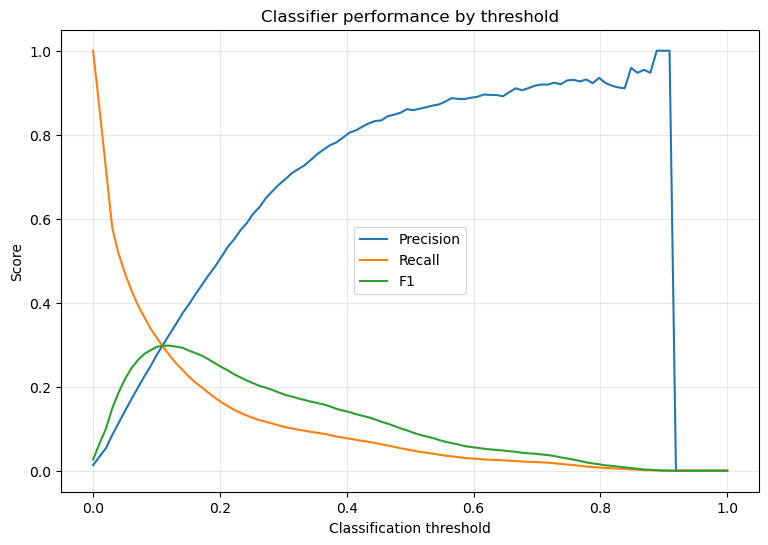

In [13]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1"
)

plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Classifier performance by threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
false_negative_mask = (y_test == 1) & (y_pred == 0)

false_negative_los = los_test[false_negative_mask]

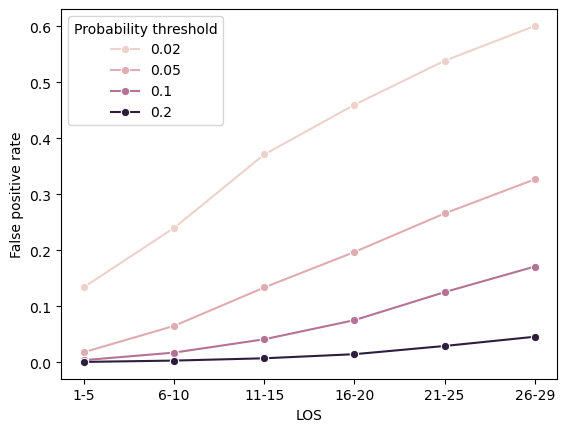

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

prob_thresholds = [0.02, 0.05, 0.10, 0.20]
bins = [(1,5), (6,10), (11,15), (16,20), (21,25), (26,29)]

rows = []

for p in prob_thresholds:

    y_pred = (y_prob >= p).astype(int)

    for lo, hi in bins:

        mask = (los_test >= lo) & (los_test <= hi)

        fp_rate = (
            ((y_test == 0) & (y_pred == 1) & mask).sum()
            / mask.sum()
        )

        rows.append({
            "Probability threshold": p,
            "LOS": f"{lo}-{hi}",
            "False positive rate": fp_rate
        })

plot_df = pd.DataFrame(rows)

sns.lineplot(
    data=plot_df,
    x="LOS",
    y="False positive rate",
    hue="Probability threshold",
    marker="o"
)

plt.show()

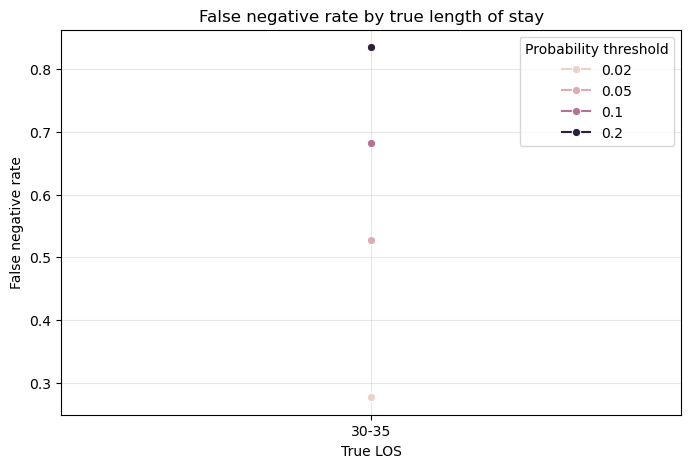

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

prob_thresholds = [0.02, 0.05, 0.10, 0.20]
bins = [(30,35), (36,40), (41,50), (51,75), (76,100), (101,1000)]

rows = []

for p in prob_thresholds:

    y_pred = (y_prob >= p).astype(int)

    for lo, hi in bins:

        mask = (los_test >= lo) & (los_test <= hi)

        if mask.sum() == 0:
            continue

        fn_rate = (
            ((y_test == 1) & (y_pred == 0) & mask).sum()
            / mask.sum()
        )

        rows.append({
            "Probability threshold": p,
            "LOS": f"{lo}-{hi}",
            "False negative rate": fn_rate
        })

plot_df = pd.DataFrame(rows)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=plot_df,
    x="LOS",
    y="False negative rate",
    hue="Probability threshold",
    marker="o"
)

plt.ylabel("False negative rate")
plt.xlabel("True LOS")
plt.title("False negative rate by true length of stay")
plt.grid(alpha=0.3)

plt.show()

## Train regression model

In [17]:
mask = y_train == 0

X_reg_train = X_train.loc[mask]
y_reg_train = los_train.loc[mask]

regression_model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=64)) 
])

regression_bayes_search = BayesSearchCV(
    estimator=regression_model_pipeline,
    search_spaces=search_space,
    n_iter=50,
    cv=skf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

In [18]:
random_indices = random.sample(range(len(y_train)), 100_000)  # Randomly sample 100,000 indices
random_indices.sort()
# random_indices

regression_bayes_search.fit(X_train.iloc[random_indices,:], y_train.iloc[random_indices])

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,Pipeline(step...m_state=42))])
,search_spaces,"{'regressor__max_depth': Integer(low=5...m='normalize'), 'regressor__n_estimators': Integer(low=1...m='normalize')}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'neg_mean_squared_error'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,StratifiedKFo... shuffle=True)


In [19]:
regressor_best_model = regression_bayes_search.best_estimator_

## Validation of the Regression

In [33]:
threshold = 0.2

y_prob = best_model.predict_proba(X_test)[:,1]  # Get the probabilities for the positive class
y_class = (y_prob >= threshold).astype(int)  # Classify based on the threshold

hybrid_pred = np.full(len(X_test), 30.0)

mask = (y_class == 0)

hybrid_pred[mask] = regressor_best_model.predict(X_test.loc[mask])

In [34]:
print("MAE:",
      mean_absolute_error(los_test, hybrid_pred))

print("QUANTILE:",
      mean_pinball_loss(los_test, hybrid_pred, alpha=0.9))

MAE: 4.664325384474422
QUANTILE: 4.1685283372700415
